From a Data Science perspective, the problem is to develop a machine-learning approach for predicting whether a patient is likely to miss a scheduled appointment.

This problem is treated as a supervised binary classification task. Historical appointment records will be used to train a model to identify patterns associated with appointment attendance and no-show behaviour. The target variable will represent whether an appointment resulted in a no-show or attendance.

The Data Science track is responsible for preparing the dataset, selecting and engineering relevant features, developing a baseline classification model, and evaluating the model's ability to predict potential patient no-shows. The results will provide an initial foundation for a data-driven solution that may help HealthConnect identify appointments with a higher risk of being missed.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LogisticRegression
import joblib

In [4]:
#load dataset
df = pd.read_csv('/content/HealthConnect_Appointment_Data.csv')

In [5]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [6]:
df.tail()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
4995,HC-04996,P-0007,Male,49,45-54,Diagnostic Test,3/29/2025,4/26/2025,Saturday,Morning,28,5,1,Yes,Email,4.4,35.0,No-Show
4996,HC-04997,P-1501,Female,52,45-54,Follow-up,12/14/2025,2/12/2026,Thursday,Evening,60,6,2,Yes,WhatsApp,12.6,24.0,Attended
4997,HC-04998,P-0315,Male,59,55-64,General Consultation,3/3/2026,3/24/2026,Tuesday,Afternoon,21,5,0,No,NaN,22.8,28.0,Attended
4998,HC-04999,P-1262,Male,47,45-54,General Consultation,12/3/2025,1/6/2026,Tuesday,Morning,34,4,1,No,NaN,12.5,16.0,Attended
4999,HC-05000,P-1793,Female,19,18-24,General Consultation,8/24/2025,9/30/2025,Tuesday,Morning,37,6,1,Yes,WhatsApp,1.1,13.0,No-Show


Rows and columns in the dataset

In [7]:
df.shape

# rows: 5000
# columns: 18

(5000, 18)

checking for duplicate

In [8]:
df.duplicated().sum()

# zero duplicates

np.int64(0)

information checks

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [10]:
df.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


missing value checks

In [11]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Display only columns with missing values
missing_values[missing_values > 0]

,0
reminder_channel,1366
distance_to_clinic_km,90
waiting_time_minutes,60


In [12]:
# Check the relationship between reminder_sent and reminder_channel
pd.crosstab(
    df['reminder_sent'],
    df['reminder_channel'].isnull(),
    margins=True
)

reminder_channel,False,True,All
reminder_sent,,,
No,0,1366,1366
Yes,3634,0,3634
All,3634,1366,5000


This means the was no reminder sent to patients.
So replace the empty spaces at reminder chennel with No Reminder

In [13]:
df['reminder_channel'] = df['reminder_channel'].fillna('No Reminder')

In [14]:
df['reminder_channel'].value_counts()

,count
reminder_channel,
SMS,2000
No Reminder,1366
WhatsApp,1101
Email,533


In [15]:
# Examine descriptive statistics for variables with missing values
df[['distance_to_clinic_km', 'waiting_time_minutes']].describe()

,distance_to_clinic_km,waiting_time_minutes
count,4910.000000,4940.000000
mean,10.109572,24.189676
std,6.590030,10.863184
min,0.500000,2.000000
25%,5.300000,17.000000
50%,8.700000,24.000000
75%,13.500000,32.000000
max,45.000000,68.000000


In [16]:
# Replace missing numerical values using the median

df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(
    df['distance_to_clinic_km'].median()
)

df['waiting_time_minutes'] = df['waiting_time_minutes'].fillna(
    df['waiting_time_minutes'].median()
)

In [17]:
# Verify that missing values have been handled
df[['distance_to_clinic_km', 'waiting_time_minutes']].isnull().sum()

,0
distance_to_clinic_km,0
waiting_time_minutes,0


Inspect Unique Values in Categorical Variables

In [18]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Display unique values
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


appointment_id
appointment_id
HC-05000    1
HC-00001    1
HC-00002    1
HC-00003    1
HC-00004    1
           ..
HC-00013    1
HC-00012    1
HC-00011    1
HC-00010    1
HC-00009    1
Name: count, Length: 5000, dtype: int64

patient_id
patient_id
P-1742    9
P-1399    9
P-1776    9
P-0252    8
P-0869    8
         ..
P-1481    1
P-0417    1
P-0093    1
P-0467    1
P-1421    1
Name: count, Length: 1696, dtype: int64

gender
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

age_group
age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

appointment_type
appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

booking_date
booking_date
8/24/2025     20
1/26/2026     19
2/16/2026     19
11/2/2025     18
2/27/2026     18
              ..
11/12/2024  

From the above output, appointment_date and booking_date needs a convention to date datatype from object(words)

Data type validation and correction

In [19]:
df.dtypes

,0
appointment_id,object
patient_id,object
gender,object
age,int64
age_group,object
appointment_type,object
booking_date,object
appointment_date,object
appointment_day,object
appointment_time,object


In [20]:
# Convert booking date and appointment date columns to datetime format
df['booking_date'] = pd.to_datetime(df['booking_date'])

df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [21]:
df[['booking_date', 'appointment_date']].dtypes

,0
booking_date,datetime64[ns]
appointment_date,datetime64[ns]


Now the date columns are set to their appropraite data types

Target Variable preparation and Treatment of Cancellation

In [22]:
print(df['appointment_outcome'].value_counts())

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64


Our defined machine-learning problem is:

Predict whether a patient will attend or miss (not show up on) a scheduled appointment.

Cancelled: The appointment was cancelled and therefore does not represent either attendance or a true no-show.

Therefore, cancelled appointments have to be removed from the dataset for the model.

A copy of the cleaned dataset

In [23]:
model_df = df.copy()

Remove cancelled appointments

In [24]:
model_df = model_df[
    model_df['appointment_outcome'] != 'Cancelled'
].copy()

check the remaining outcomes

In [25]:
model_df['appointment_outcome'].value_counts()

,count
appointment_outcome,
No-Show,2423
Attended,2314


Total appointments(observations) = 4737

attended appointment = 2314

missed (no show) appointment = 2423

Create the Binary target variable

no show as 0

attended as 1


In [26]:
model_df['no_show'] = model_df['appointment_outcome'].map({
    'Attended': 1,
    'No-Show': 0
})


In [27]:
# Verify the target distribution
model_df['no_show'].value_counts()

,count
no_show,
0,2423
1,2314


In [28]:
# Target variable distribution in percentage
model_df['no_show'].value_counts(normalize=True) * 100

,proportion
no_show,
0,51.150517
1,48.849483


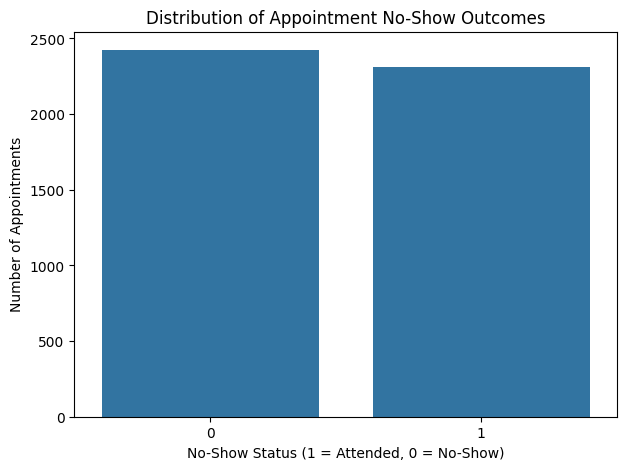

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=model_df,
    x='no_show'
)

plt.title('Distribution of Appointment No-Show Outcomes')
plt.xlabel('No-Show Status (1 = Attended, 0 = No-Show)')
plt.ylabel('Number of Appointments')

plt.show()

Data leakage and Feature Selection

In [30]:
df.columns

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'booking_date', 'appointment_date',
       'appointment_day', 'appointment_time', 'booking_lead_days',
       'previous_appointments', 'previous_no_shows', 'reminder_sent',
       'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes',
       'appointment_outcome'],
      dtype='object')

Excluded columns

Appointment ID

 It's a unique identifer which does not contain meaningful behavioural information for predictin no-shows

Appointment Outcome

This is the original outcome variable from which we create target



In [31]:
exclude_columns = [
    'appointment_id',
    'appointment_outcome',
    'patient_id'
]

Remaining candidate features

In [32]:

candidate_features = [
    column for column in model_df.columns
    if column not in exclude_columns + ['no_show']
]

candidate_features

['gender',
 'age',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'reminder_sent',
 'reminder_channel',
 'distance_to_clinic_km',
 'waiting_time_minutes']

Data Exploration and Visualization

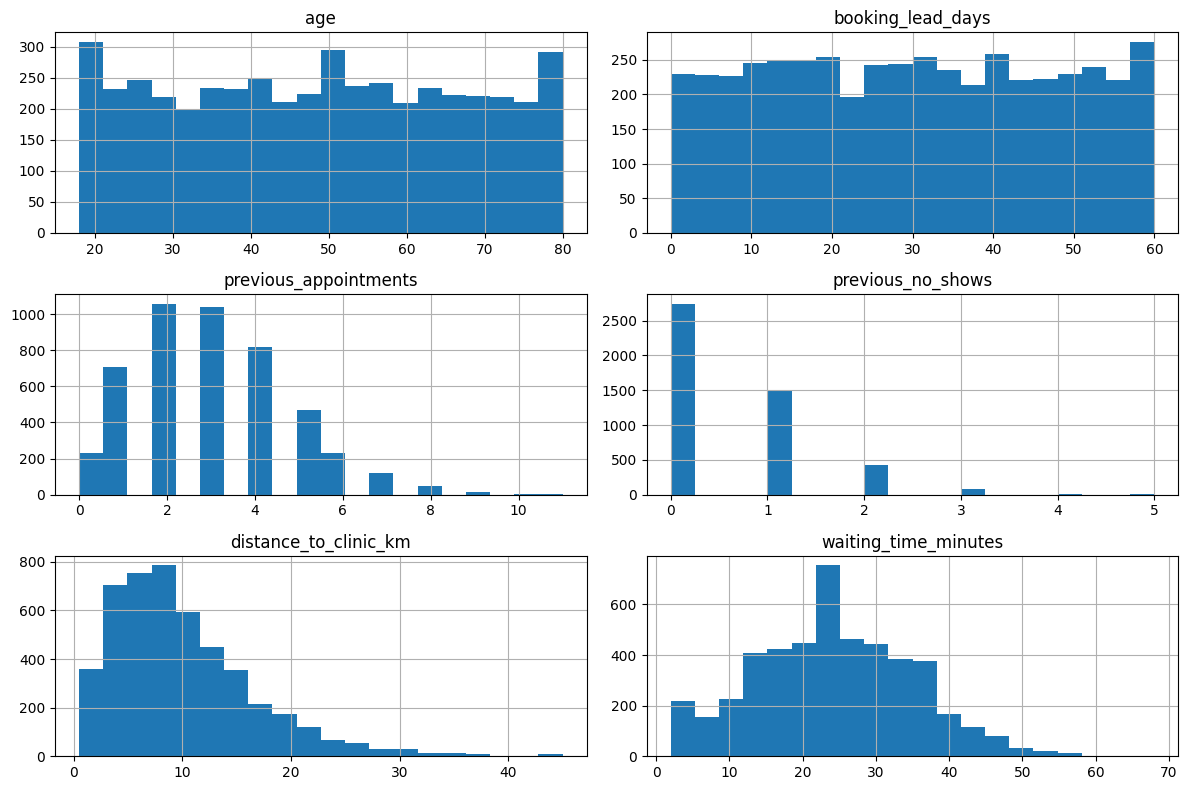

In [33]:
numerical_cols = [
    'age',
    'booking_lead_days',
    'previous_appointments',
    'previous_no_shows',
    'distance_to_clinic_km',
    'waiting_time_minutes'
]

model_df[numerical_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

Purpose:

Identify skewness and potential outliers that may affect preprocessing.

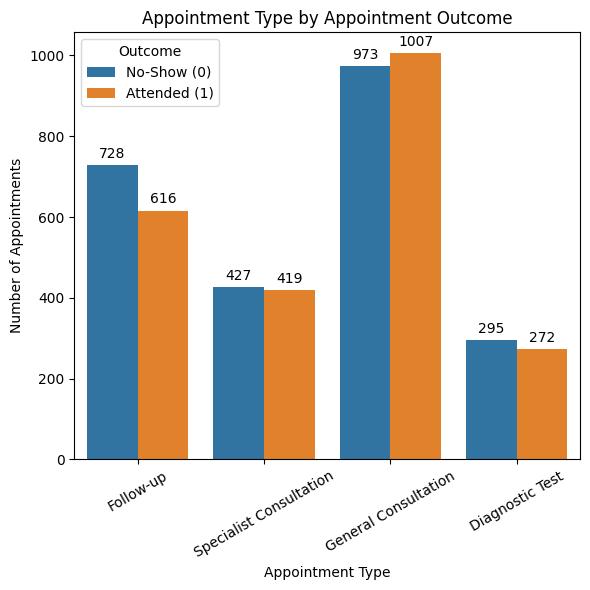

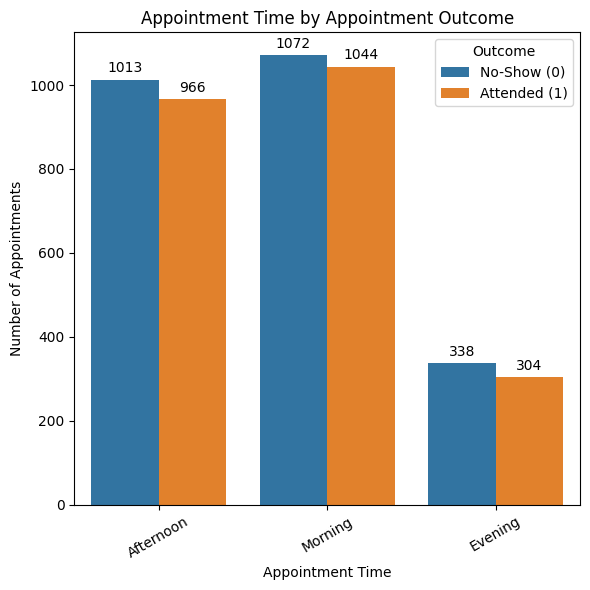

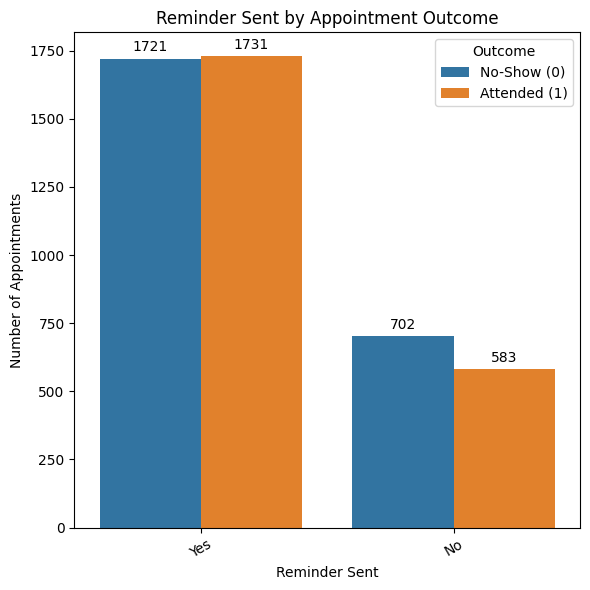

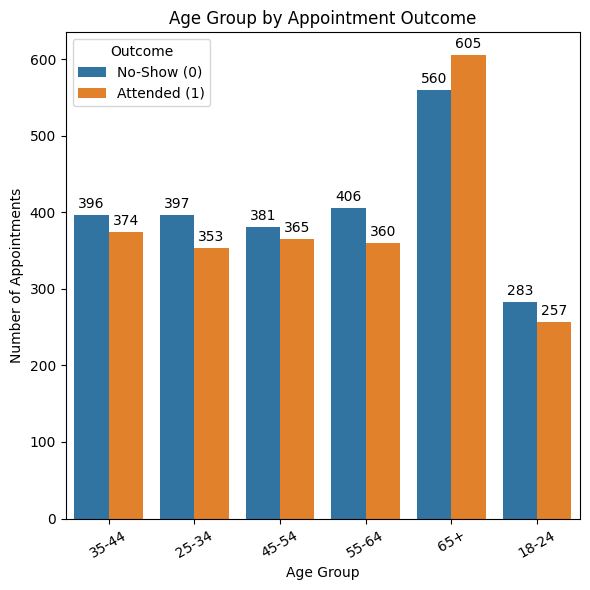

In [34]:
features_to_plot = [
    'appointment_type',
    'appointment_time',
    'reminder_sent',
    'age_group'
]

for col in features_to_plot:
    plt.figure(figsize=(6,6))

    ax = sns.countplot(
        data=model_df,
        x=col,
        hue='no_show'
    )

    # Add values on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)

    plt.title(f'{col.replace("_", " ").title()} by Appointment Outcome')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Number of Appointments')
    plt.xticks(rotation=30)
    plt.legend(title='Outcome', labels=['No-Show (0)', 'Attended (1)'])
    plt.tight_layout()
    plt.show()

Previous No Show verse Appointment Outcome

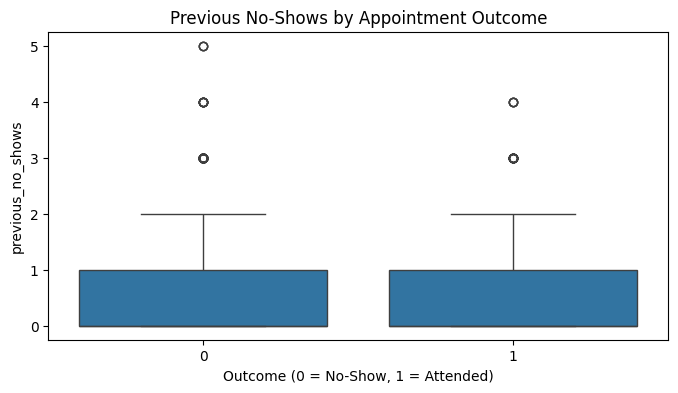

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(data=model_df, x='no_show', y='previous_no_shows')
plt.title('Previous No-Shows by Appointment Outcome')
plt.xlabel('Outcome (0 = No-Show, 1 = Attended)')
plt.show()

The distribution of previous no-shows appears similar for both appointment outcomes. This suggests that, based on this visualization alone, `previous_no_shows` may have limited predictive power as an individual feature. However, it will be retained for further evaluation because its predictive value may become more evident when combined with other features in the machine-learning model.


Feature Enineering

In [36]:
# Extract months from both Booking and Appointment date features
model_df['booking_month'] = model_df['booking_date'].dt.month
model_df['appointment_month'] = model_df['appointment_date'].dt.month

In [37]:
# Verify booking lead days
calculated_lead_days = (
    model_df['appointment_date'] - model_df['booking_date']
).dt.days

(calculated_lead_days == model_df['booking_lead_days']).value_counts()

,count
True,4737


No Show History Rate

In [38]:
# Create historical no-show rate
model_df['previous_no_show_rate'] = (
    model_df['previous_no_shows'] /
    model_df['previous_appointments'].replace(0, np.nan)
)

# Replace undefined values with 0
model_df['previous_no_show_rate'] = (
    model_df['previous_no_show_rate'].fillna(0)
)

This represents the proportion of previous appointments that resulted in no-shows.

Remove raw Date columns

In [39]:
model_df = model_df.drop(
    columns=['booking_date', 'appointment_date']
)

In [40]:
model_df.columns

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'appointment_day', 'appointment_time',
       'booking_lead_days', 'previous_appointments', 'previous_no_shows',
       'reminder_sent', 'reminder_channel', 'distance_to_clinic_km',
       'waiting_time_minutes', 'appointment_outcome', 'no_show',
       'booking_month', 'appointment_month', 'previous_no_show_rate'],
      dtype='object')

Feature Selection and Encoding

In [41]:
# Define columns to exclude
drop_columns = [
    'appointment_id',
    'patient_id',
    'appointment_outcome',
    'no_show'
]

# Features
X = model_df.drop(columns=drop_columns)

# Target
y = model_df['no_show']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4737, 16)
Target shape: (4737,)


In [42]:
X.dtypes

,0
gender,object
age,int64
age_group,object
appointment_type,object
appointment_day,object
appointment_time,object
booking_lead_days,int64
previous_appointments,int64
previous_no_shows,int64
reminder_sent,object


Categorical Variables

In [43]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
categorical_features

['gender',
 'age_group',
 'appointment_type',
 'appointment_day',
 'appointment_time',
 'reminder_sent',
 'reminder_channel']

Encode categorical Variable into numeric

Using one-hot encoding  

In [44]:
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Final feature shape:", X.shape)

Final feature shape: (4737, 31)


In [45]:
X.head()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes,booking_month,appointment_month,previous_no_show_rate,gender_Male,...,appointment_day_Sunday,appointment_day_Thursday,appointment_day_Tuesday,appointment_day_Wednesday,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_No Reminder,reminder_channel_SMS,reminder_channel_WhatsApp
0,39,12,2,0,19.3,29.0,2,2,0.000000,False,...,False,False,True,False,False,False,True,False,False,True
1,31,2,6,0,14.3,42.0,2,2,0.000000,True,...,False,False,False,False,False,True,True,False,True,False
2,50,38,5,1,11.4,11.0,11,12,0.200000,False,...,False,False,False,True,False,True,True,False,True,False
3,59,41,3,1,7.4,35.0,7,8,0.333333,True,...,False,True,False,False,True,False,True,False,True,False
4,34,47,3,1,5.6,27.0,7,8,0.333333,False,...,False,False,False,False,False,False,True,False,False,False


check missing values

In [46]:
print("Missing values in features:", X.isnull().sum().sum())
print("Missing values in target:", y.isnull().sum())

Missing values in features: 0
Missing values in target: 0


The final predictor dataset was created by removing identifier variables and the original appointment outcome variable to prevent irrelevant information and target leakage. Categorical variables were transformed using one-hot encoding to make them suitable for machine-learning algorithms. The resulting dataset contained only numerical features and was confirmed to contain no missing values.

Train-Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

Target Distribution

In [48]:
print("Training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training set:
no_show
0    1938
1    1851
Name: count, dtype: int64
no_show
0    0.511481
1    0.488519
Name: proportion, dtype: float64

Testing set:
no_show
0    485
1    463
Name: count, dtype: int64
no_show
0    0.511603
1    0.488397
Name: proportion, dtype: float64


Baseline Model

create the model

In [49]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

Train the model

In [50]:
logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

Generate predictions

In [51]:
y_pred = logistic_model.predict(X_test)

y_prob =

 the probability that an appointment belongs to class 1 (Attended)

In [52]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

Evaluate the model

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [54]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.5918
Precision: 0.5844
Recall: 0.568
F1-Score: 0.5761
ROC-AUC: 0.6533


In [55]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No-Show", "Attended"]
))

              precision    recall  f1-score   support

     No-Show       0.60      0.61      0.61       485
    Attended       0.58      0.57      0.58       463

    accuracy                           0.59       948
   macro avg       0.59      0.59      0.59       948
weighted avg       0.59      0.59      0.59       948



In [56]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[298 187]
 [200 263]]


In [57]:
no_show_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

print("No-Show Recall:", round(no_show_recall, 4))

No-Show Recall: 0.6144


The baseline Logistic Regression model achieved a No-Show recall of 61.44%. This indicates that the model correctly identified 61.44% of patients who actually missed their appointments. However, approximately 38.56% of actual No-Show cases were not identified by the model. Therefore, although the baseline model provides useful predictive information, further model development and comparison are required to determine whether a model with stronger No-Show detection can be achieved.

Decision Tree Model

In [58]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [59]:
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["No-Show", "Attended"]
))

              precision    recall  f1-score   support

     No-Show       0.61      0.62      0.62       485
    Attended       0.60      0.59      0.59       463

    accuracy                           0.61       948
   macro avg       0.61      0.61      0.61       948
weighted avg       0.61      0.61      0.61       948



In [60]:
no_show_recall_dt = recall_score(
    y_test,
    y_pred_dt,
    pos_label=0
)

print("Decision Tree No-Show Recall:",
      round(no_show_recall_dt, 4))

Decision Tree No-Show Recall: 0.6247


The Decision Tree correctly identifies 62.47% of patients who actually miss their appointments. Therefore, approximately 37.53% of actual No-Shows are still incorrectly predicted as Attended.

Random Forest Model

In [61]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [62]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No-Show", "Attended"]
))

              precision    recall  f1-score   support

     No-Show       0.59      0.61      0.60       485
    Attended       0.58      0.56      0.57       463

    accuracy                           0.58       948
   macro avg       0.58      0.58      0.58       948
weighted avg       0.58      0.58      0.58       948



In [63]:
no_show_recall_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label=0
)

print(
    "Random Forest No-Show Recall:",
    round(no_show_recall_rf, 4)
)

Random Forest No-Show Recall: 0.6082


The Random Forest correctly identifies 60.82% of actual No-Show appointments.

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": (y_pred, y_prob),
    "Decision Tree": (y_pred_dt, y_prob_dt),
    "Random Forest": (y_pred_rf, y_prob_rf)
}

results = []

for name, (pred, prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "No-Show Precision": precision_score(
            y_test, pred, pos_label=0
        ),
        "No-Show Recall": recall_score(
            y_test, pred, pos_label=0
        ),
        "No-Show F1": f1_score(
            y_test, pred, pos_label=0
        ),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

import pandas as pd

comparison_df = pd.DataFrame(results)

print(comparison_df.round(4))

                 Model  Accuracy  No-Show Precision  No-Show Recall  \
0  Logistic Regression    0.5918             0.5984          0.6144   
1        Decision Tree    0.6065             0.6134          0.6247   
2        Random Forest    0.5844             0.5912          0.6082   

   No-Show F1  ROC-AUC  
0      0.6063   0.6533  
1      0.6190   0.6417  
2      0.5996   0.6228  


The Decision Tree produces the strongest results for most classification metrics. It has the highest:

Accuracy: 60.65%
No-Show Precision: 61.34%
No-Show Recall: 62.47%
No-Show F1-score: 61.90%

This means the Decision Tree is currently the strongest model for identifying No-Show appointments.

However, Logistic Regression has the highest ROC-AUC (0.6533). This indicates that Logistic Regression has the strongest overall ability among these three models to distinguish between No-Show and Attended appointments across different classification thresholds.

Hyperparameter tuning

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
from sklearn.tree import DecisionTreeClassifier

# Optimize recall for No-Show (class 0)
no_show_recall = make_scorer(
    recall_score,
    pos_label=0
)

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring=no_show_recall,
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best Cross-Validation No-Show Recall:", grid_dt.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Cross-Validation No-Show Recall: 0.6207371000825809


In [71]:
best_dt = grid_dt.best_estimator_

y_pred_tuned = best_dt.predict(X_test)

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["No-Show", "Attended"]
))

              precision    recall  f1-score   support

     No-Show       0.57      0.58      0.57       485
    Attended       0.55      0.54      0.54       463

    accuracy                           0.56       948
   macro avg       0.56      0.56      0.56       948
weighted avg       0.56      0.56      0.56       948



In [67]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["No-Show", "Attended"]
))

              precision    recall  f1-score   support

     No-Show       0.57      0.58      0.57       485
    Attended       0.55      0.54      0.54       463

    accuracy                           0.56       948
   macro avg       0.56      0.56      0.56       948
weighted avg       0.56      0.56      0.56       948



Final model evaluation

The Final Model Selection

<Figure size 700x500 with 0 Axes>

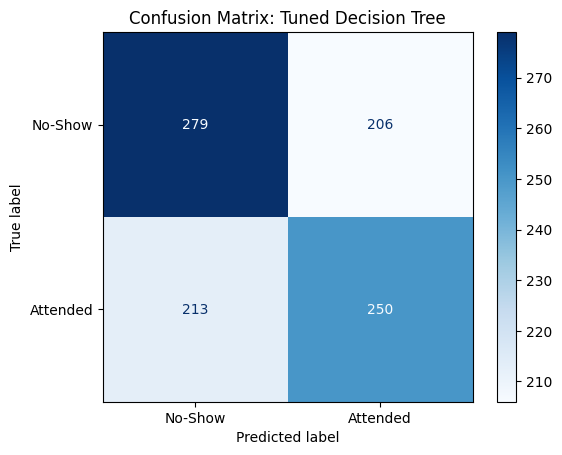

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=["No-Show", "Attended"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix: Tuned Decision Tree")
plt.show()

Based on the current results, the Decision Tree is the preferred model for this project because it achieved the highest:

Accuracy: 60.65%
No-Show Precision: 61.34%
No-Show Recall: 62.47%
No-Show F1-score: 61.90%

Logistic Regression had the highest ROC-AUC (0.6533), but the Decision Tree performed better on the metrics most directly related to identifying No-Shows.

In [74]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,booking_lead_days,0.212367
4,distance_to_clinic_km,0.159219
0,age,0.132050
5,waiting_time_minutes,0.101675
7,appointment_month,0.055095
8,previous_no_show_rate,0.048465
6,booking_month,0.044746
2,previous_appointments,0.037394
23,appointment_day_Tuesday,0.018858
16,appointment_type_Follow-up,0.015988


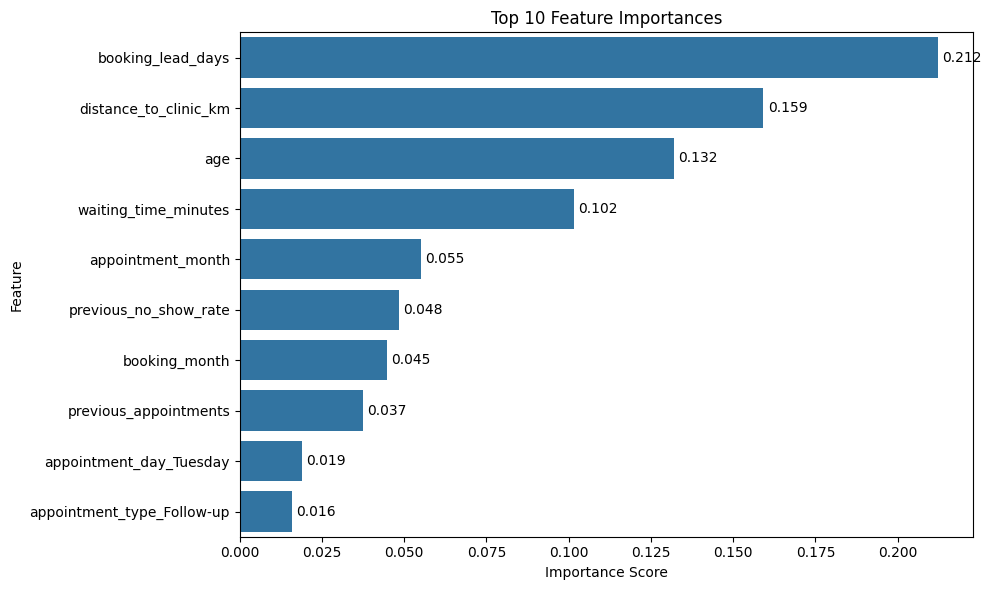

In [75]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# Add values
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

Save the final model

In [76]:
import joblib

# Save the trained model
joblib.dump(best_dt, 'healthconnect_no_show_model.pkl')

print("Model saved successfully!")

Model saved successfully!


Save the feature columns

In [77]:
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Feature list saved successfully!")

Feature list saved successfully!
